In [1]:
import numpy as np
import pandas as pd

# Criteria Names
criteria = ["Waste Count (WC)",
            "Waste Type Weight (WTW)",
            "Location Sensitivity (LS)",
            "Historical Frequency (HF)"]

# Pairwise Comparison Matrix
A = np.array([
    [1,   2,   3,   4],
    [1/2, 1,   2,   3],
    [1/3, 1/2, 1,   2],
    [1/4, 1/3, 1/2, 1]
])

print("Pairwise Comparison Matrix")
df = pd.DataFrame(A, index=criteria, columns=criteria)
print(df)

Pairwise Comparison Matrix
                           Waste Count (WC)  Waste Type Weight (WTW)  \
Waste Count (WC)                   1.000000                 2.000000   
Waste Type Weight (WTW)            0.500000                 1.000000   
Location Sensitivity (LS)          0.333333                 0.500000   
Historical Frequency (HF)          0.250000                 0.333333   

                           Location Sensitivity (LS)  \
Waste Count (WC)                                 3.0   
Waste Type Weight (WTW)                          2.0   
Location Sensitivity (LS)                        1.0   
Historical Frequency (HF)                        0.5   

                           Historical Frequency (HF)  
Waste Count (WC)                                 4.0  
Waste Type Weight (WTW)                          3.0  
Location Sensitivity (LS)                        2.0  
Historical Frequency (HF)                        1.0  


In [2]:
column_sums = A.sum(axis=0)

print("Column Sums")
print(column_sums)

Column Sums
[ 2.08333333  3.83333333  6.5        10.        ]


In [3]:
normalized_matrix = A / column_sums

print("Normalized Matrix")
print(pd.DataFrame(normalized_matrix,
                   index=criteria,
                   columns=criteria))

Normalized Matrix
                           Waste Count (WC)  Waste Type Weight (WTW)  \
Waste Count (WC)                       0.48                 0.521739   
Waste Type Weight (WTW)                0.24                 0.260870   
Location Sensitivity (LS)              0.16                 0.130435   
Historical Frequency (HF)              0.12                 0.086957   

                           Location Sensitivity (LS)  \
Waste Count (WC)                            0.461538   
Waste Type Weight (WTW)                     0.307692   
Location Sensitivity (LS)                   0.153846   
Historical Frequency (HF)                   0.076923   

                           Historical Frequency (HF)  
Waste Count (WC)                                 0.4  
Waste Type Weight (WTW)                          0.3  
Location Sensitivity (LS)                        0.2  
Historical Frequency (HF)                        0.1  


In [4]:
weights = normalized_matrix.mean(axis=1)

weights_df = pd.DataFrame({
    "Criteria": criteria,
    "Weight": weights
})

print(weights_df)

                    Criteria    Weight
0           Waste Count (WC)  0.465819
1    Waste Type Weight (WTW)  0.277140
2  Location Sensitivity (LS)  0.161070
3  Historical Frequency (HF)  0.095970


In [5]:
weighted_sum = np.dot(A, weights)

consistency_vector = weighted_sum / weights

lambda_max = np.mean(consistency_vector)

print("Lambda Max =", lambda_max)

Lambda Max = 4.03103950215422


In [6]:
n = 4

CI = (lambda_max - n)/(n-1)

print("Consistency Index (CI) =", CI)

Consistency Index (CI) = 0.010346500718073415


In [7]:
RI = 0.90   # Random Index for n=4

CR = CI / RI

print("Consistency Ratio (CR) =", CR)

Consistency Ratio (CR) = 0.011496111908970461


In [8]:
if CR < 0.10:
    print("The AHP matrix is Consistent.")
else:
    print("The AHP matrix is NOT Consistent.")

The AHP matrix is Consistent.


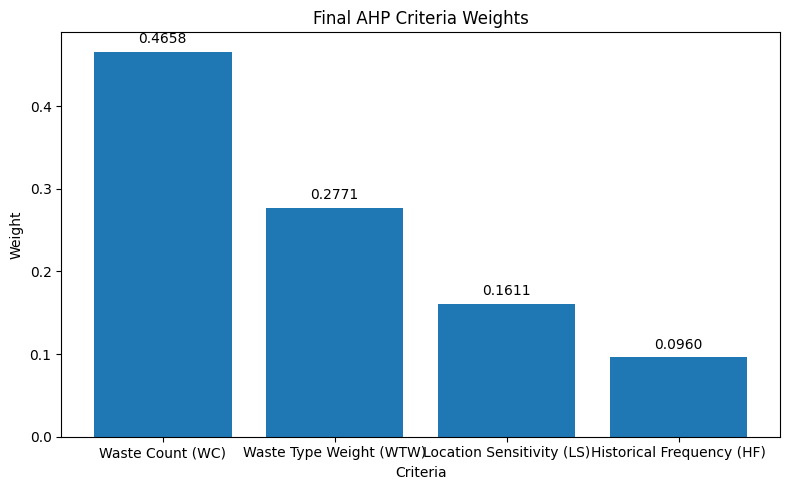

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(criteria, weights)

plt.title("Final AHP Criteria Weights")
plt.ylabel("Weight")
plt.xlabel("Criteria")

for i, v in enumerate(weights):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()